# **Spectral embedding para la descripción de imágenes**

Este trabajo trata sobre el *spectral embedding* (también llamado *laplacian eigenmap*), un algoritmo de **aprendizaje no supervisado** dentro de lo que se conoce como aprendizaje de variedades (*manifold learning*). Este algoritmo es ideal cuando queremos reducir la dimensionalidad de un conjunto de datos que presenta una estructura no lineal, pues encuentra una variedad de menor dimensión que el espacio original en el que se encuentran los datos, donde se preserva en la medida de lo posible la "cercanía" local de los mismos. Esto nos permite obtener una representación más simple de los datos, lo que nos facilita su visualización, análisis e interpretación.

Recomendamos complementar la lectura de este notebook con la de la [presentación](https://github.com/Math-Machine-Learning-2026/spectral-embedding/blob/main/docs/Spectral_embedding.pdf), para una mejor comprensión y asimilación de los conceptos. En particular, en la presentación explicamos los fundamentos teóricos en los que se basa este algoritmo, además de detallar el dataset con el que trabajamos.

**1. Carga, visualización y preparación de los datos**

Lo primero que haremos es cargar los datos del dataset [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist?tab=readme-ov-file) y dejarlos bien preparados para después trabajar con ellos.

In [ ]:
import numpy as np
import pandas as pd

# fetch_openml descarga datasets de un repositorio público, a partir de un id único del mismo
from sklearn.datasets import fetch_openml

# Semilla global para garantizar reproducibilidad en los experimentos
RANDOM_STATE = 42

# Cargamos el dataset Fashion-MNIST
# return_X_y hace que esta función devuelva en X la matriz de atributos y en y el vector de labels
# esta función nos devuelve cada imagen como un vector de IR^784, en forma de numpy array
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)

# Conversión de tipos
X = X.astype(np.float32)
y = y.astype(int)

In [ ]:
# Comprobamos que las dimensiones de la matriz X y el vector y son las deseadas
print("Forma de la matriz de atributos X:", X.shape)
print("Forma del vector de etiquetas y:", y.shape)

Forma de la matriz de atributos X: (70000, 784)
Forma del vector de etiquetas y: (70000,)


La matriz de atributos tiene 70.000 filas (una por cada imagen del *dataset*) y 784 columnas (una por cada píxel, pues el tamaño de las imágenes es de 28x28), ya que como hemos comentado, `fetch_openml` nos devuelve las imágenes como vectores de píxeles en $\mathbb{R}^{784}$.

Cada una de las imágenes del conjunto de datos lleva asociada una etiqueta, así que prestemos un poco de atención a esto.

In [ ]:
# Mostramos que en el dataset hay efectivamente 10 clases, etiquetadas del 0 al 9
print("Etiquetas distintas encontradas en el dataset:", np.unique(y))

# Contamos cuántas muestras hay de cada clase, convirtiendo las etiquetas en una serie
# value_counts() cuenta cuántas veces aparece cada etiqueta y sort_index() ordena por el valor de la etiqueta
print("Número de muestras por clase:")
print(pd.Series(y).value_counts().sort_index())

Etiquetas distintas encontradas en el dataset: [0 1 2 3 4 5 6 7 8 9]
Número de muestras por clase:
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


Como podemos ver tras ejecutar la celda anterior, el número de imágenes de cada clase está balanceado. Esto es, hay el mismo número de imágenes de cada una de las clases en el conjunto de datos.

Las etiquetas de las imágenes son los enteros $0, \cdots, 9$. No obstante, nos puede ser de utilidad transformarlas a sus nombres reales de prenda, de cara a algunas imágenes y gráficos.

In [ ]:
# Creamos un diccionario que asocie a cada etiqueta numérica su nombre de clase
label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Recorremos las clases únicas presentes en y
for label in np.unique(y):
    # Mostramos el id numérico de la clase y su nombre asociado
    print(f"Clase {label}: {label_names[label]}")

Clase 0: T-shirt/top
Clase 1: Trouser
Clase 2: Pullover
Clase 3: Dress
Clase 4: Coat
Clase 5: Sandal
Clase 6: Shirt
Clase 7: Sneaker
Clase 8: Bag
Clase 9: Ankle boot


Visualicemos ahora algunas imágenes del *dataset*. Estos nos permitirá comprobar si la carga de los datos ha sido correcta, si las etiquetas son coherentes y si el conjunto de datos tiene la apariencia esperada.

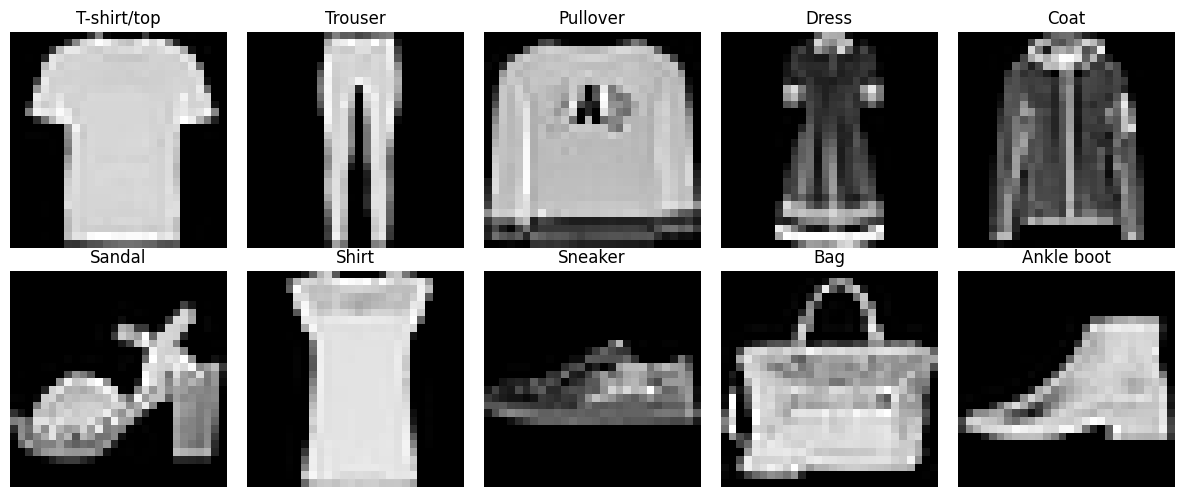

In [ ]:
import matplotlib.pyplot as plt

# Creamos un generador aleatorio para la visualización de las imágenes, de forma
# que siempre se muestren las mismas
rng_visual = np.random.RandomState(RANDOM_STATE)

# Creamos una lista vacía donde guardaremos los índices elegidos, para luego
# mostrar esas mismas imágenes
selected_plot_indices = []

# Creamos una figura con 2 filas y 5 columnas para mostrar una imagen de cada clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Recorremos todas las clases
for class_id, ax in enumerate(axes.ravel()):
    # Buscamos los índices de todas las muestras cuya etiqueta es class_id
    class_indices = np.where(y == class_id)[0]

    # Elegimos una muestra aleatoria dentro de esa clase
    chosen_idx = rng_visual.choice(class_indices)

    # Guardamos el índice elegido para poder reutilizarlo más adelante
    selected_plot_indices.append(chosen_idx)

    # Recuperamos la imagen como matriz de 28x28 píxeles
    image = X[chosen_idx].reshape(28, 28)

    # Dibujamos la imagen en escala de grises, aquí los píxeles toman valores
    # en [0,255]
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)

    # Mostramos el nombre de la clase en el título
    ax.set_title(label_names[class_id])

    # Ocultamos los ejes
    ax.axis("off")

# Evitamos solapamientos de títulos e imágenes
plt.tight_layout()

# Mostramos la figura
plt.show()

# Convertimos la lista de índices a array por comodidad
selected_plot_indices = np.array(selected_plot_indices)

El siguiente paso importante es ver en qué rango están los valores de los datos, pues lo típico es que los píxeles tomen valores entre 0 y 255. Esto es importante, porque la escala influirá cuando calculemos distancias entre imágenes.

In [ ]:
# Mostramos el menor valor para un píxel presente en la matriz X
print("Valor mínimo en X:", X.min())
# Mostramos el mayor valor para un píxel presente en la matriz X
print("Valor máximo en X:", X.max())

Valor mínimo en X: 0.0
Valor máximo en X: 255.0


Ahora, reescalamos los datos de los que disponemos, pues trabajaremos con distancias en la construcción del grafo. Así, haremos que los píxeles pasen de tomar valores en $[0,255]$ a tomar valores en $[0,1]$, lo que significa que estamos aplicando un reescalado global uniforme de manera que todos ellos cambien con el mismo factor.

Una estandarización no es lo más conveniente en este caso, pues cada píxel queda modificado por su media y desviación típica en el *dataset*, lo que puede alterar las distancias que se usen luego para construir el grafo.

El uso del reescalado en lugar de la estandarización es habitual al trabajar con algoritmos espectrales de aprendizaje no supervisado, como se puede ver en los repositorios https://github.com/sidzekrom/spectral-clustering/blob/master/mnistHandwriting.py y https://github.com/sdimi/handwritten-digits-recognition/blob/master/cluster_mnist.py, donde trabajan con un *dataset* de dígitos ([MNIST](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)) en lugar de con uno de ropa.

In [ ]:
# Guardamos una copia de los datos sin normalizar por si lo necesitamos más adelante
X_raw = X.copy()

# Reescalamos todos los píxeles al intervalo [0,1]
X = X / 255.0

# Mostramos una comprobación rápida del rango de valores tras normalizar
print("Valor mínimo en X tras normalización:", X.min())
print("Valor máximo en X tras normalización:", X.max())

Valor mínimo en X tras normalización: 0.0
Valor máximo en X tras normalización: 1.0


El reescalado de los píxeles no afecta a la visualización de las imágenes del *dataset*. Podemos comprobarlo a continuación, representando las mismas 10 imágenes que antes.

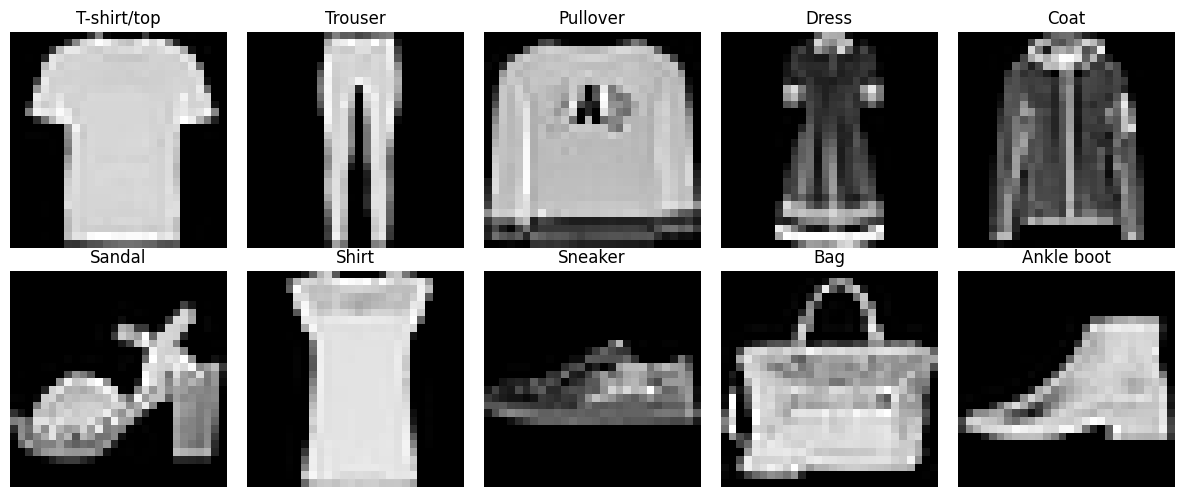

In [ ]:
# Creamos una nueva figura con 2 filas y 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Recorremos simultáneamente cada clase y cada eje de la figura
for class_id, ax in enumerate(axes.ravel()):
    # Recuperamos el mismo índice elegido en la primera visualización
    idx = selected_plot_indices[class_id]

    # Recuperamos la imagen normalizada como matriz de 28x28 píxeles
    image = X[idx].reshape(28, 28)

    # Dibujamos la imagen en escala de grises, ahora los píxeles toman valores
    # en [0,1]
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)

    # Mostramos el nombre de la clase
    ax.set_title(label_names[class_id])

    # Ocultamos los ejes
    ax.axis("off")

# Ajustamos el diseño
plt.tight_layout()

# Mostramos la figura
plt.show()

**2. Construcción del grafo**

Para aplicar el algoritmo del *spectral embedding*, es esencial construir el grafo con pesos asociado a los datos (imágenes). Dicho grafo, que se puede considerar como una aproximación discreta a una variedad de menor dimensión embebida en un espacio de mayor dimensión ($\mathbb{R}^{784}$), está caracterizado por los vértices y la matriz de afinidad. Para preservar la geometría de los datos, se conectan aquellos puntos próximos entre sí, de forma que quede recogida la estructura local del *dataset*.

El grafo que construiremos es de tipo $k-nn$ y no de tipo $\varepsilon-graph$. Esto se debe a que, como comenta este [artículo](https://www2.imm.dtu.dk/projects/manifold/Papers/Laplacian.pdf), el grafo de $k$ vecinos más cercanos tiende a quedar menos desconectado, mientras que el $\varepsilon-graph$ a menudo produce varias componentes conexas.

También tenemos que elegir una noción de distancia. El `NearestNeighbors` usa por defecto la distancia de Minkowski con $p=2$ (la distancia euclídea), a pesar de que en nuestro contexto puede hacer que perdamos interpretación geométrica. Este [paper](https://arxiv.org/html/2603.03056v1#:~:text=Cosine%20distance%20scales%20distances%20to,proper%20metric%20is%20not%20usable.) ofrece otra alternativa: la distancia coseno. Así, trabajaremos con ambas, para luego decidir cuál de las dos resulta más interesante en nuestro caso.

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Valores de k a estudiar
k_values = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 85, 100]

# Tomamos el mayor valor de k para calcular todos los vecinos de una vez
k_max = max(k_values)

In [ ]:
# Vecinos con distancia euclídea
nn_eu = NearestNeighbors(n_neighbors=k_max, metric="euclidean", n_jobs=-1)
# Ajusta el algoritmo de vecinos más cercanos a todo el dataset
nn_eu.fit(X)

# Obtenemos las distancias y los índices de los vecinos (imágenes en el dataset)
# más cercanos a cada dato, usando la métrica euclídea
# dist_eu, ind_eu son matrices de tamaño 70.000x100
dist_eu, ind_eu = nn_eu.kneighbors(X)


# Vecinos con distancia coseno
nn_co = NearestNeighbors(n_neighbors=k_max, metric="cosine", n_jobs=-1)
# Ajusta el algoritmo de vecinos más cercanos al dataset
nn_co.fit(X)

# Obtenemos las distancias y los índices de los vecinos más cercanos a cada dato,
# usando la distancia coseno
dist_co, ind_co = nn_co.kneighbors(X)

Ahora, representamos los histogramas de la distancia al vecino $k$-ésimo para cada una de las dos métricas. La idea es observar, en cada caso, si al aumentar $k$ seguimos moviéndonos dentro de una vecindad local razonable o si, por el contrario, la distancia empieza a crecer demasiado.

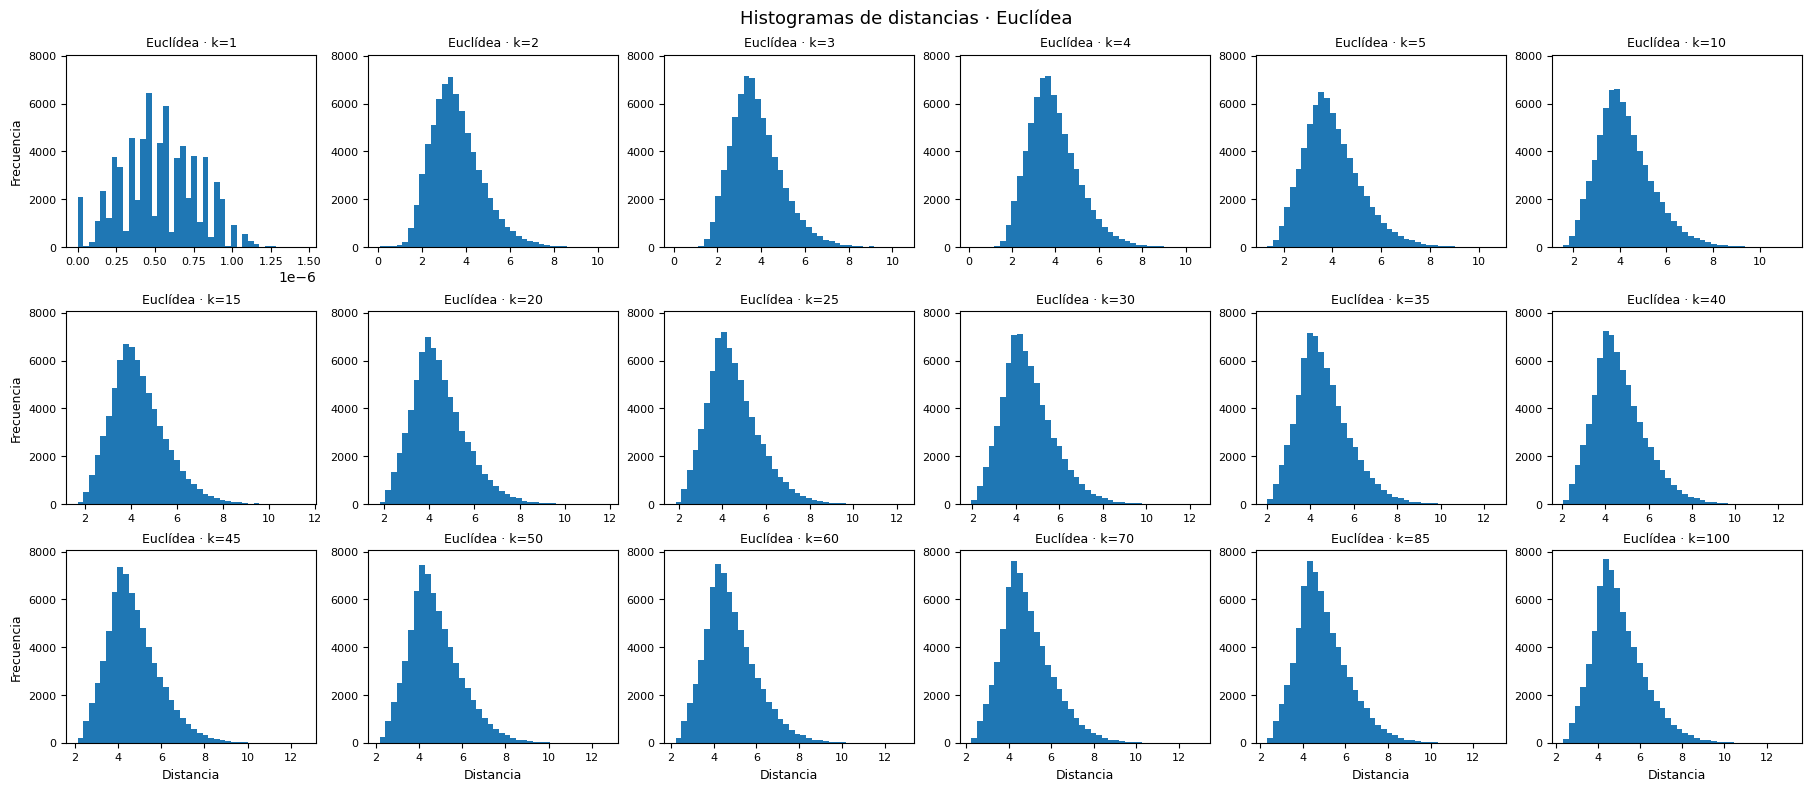

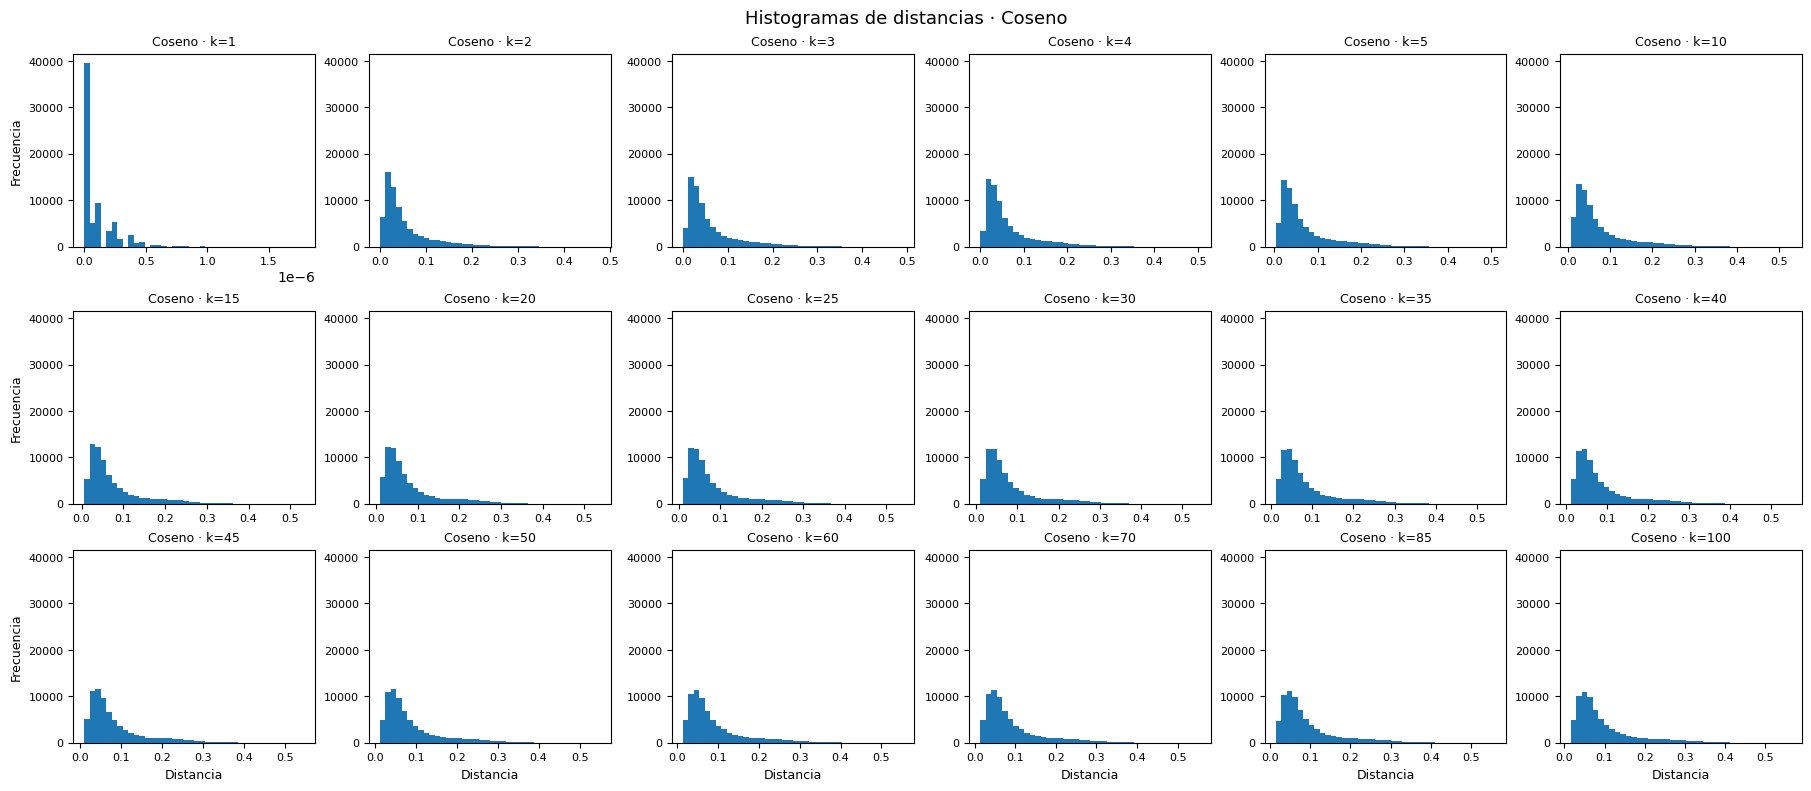

In [ ]:
nrows = 3
ncols = 6

def plot_hist_grid(dist_matrix, k_values, titulo_metrica, bins=40):
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.0 * ncols, 2.6 * nrows),
        layout="constrained"
    )

    axes = np.asarray(axes)

    # Calculamos el máximo del eje y para toda la métrica
    max_count = 0
    for k in k_values:
        # Construimos el histograma, para ello, obtenemos las distancias a los
        # k-ésimos vecinos de todos los puntos y utilizamos 40 barras para representarlas
        counts, _ = np.histogram(dist_matrix[:, k-1], bins=bins)
        # Queremos la misma escala para todos los histogramas asociados a una
        # misma distancia, de ahí que en este bucle estemos buscando el máximo
        max_count = max(max_count, counts.max())
    # Pequeño margen visual
    max_count *= 1.05

    # Dibujamos histogramas
    for j, k in enumerate(k_values):
        r, c = divmod(j, ncols)
        # Aquí es donde estamos pintando el histograma
        axes[r, c].hist(dist_matrix[:, k-1], bins=bins)
        axes[r, c].set_title(f"{titulo_metrica} · k={k}", fontsize=9)
        axes[r, c].set_ylim(0, max_count)
        axes[r, c].tick_params(labelsize=8)

    # Etiquetas
    for r in range(nrows):
        if axes[r, 0].get_visible():
            axes[r, 0].set_ylabel("Frecuencia", fontsize=9)

    for c in range(ncols):
        if axes[-1, c].get_visible():
            axes[-1, c].set_xlabel("Distancia", fontsize=9)

    fig.suptitle(f"Histogramas de distancias · {titulo_metrica}", fontsize=13)
    plt.show()

# Llamamos a la función que pinta los histogramas
plot_hist_grid(dist_eu, k_values, "Euclídea")
plot_hist_grid(dist_co, k_values, "Coseno")

A la vista de los histogramas anteriores, no identificamos un único valor óptimo del hiperparámetro $k$ con el que trabajar con cada una de las distancias, pero sí varios candidatos que pueden resultar naturales. Como queremos mantener el equilibrio entre evitar vecindarios muy pequeños y mantener la localidad entre los datos (imágenes) del grafo, podemos elegir $k=10$ para la distancia euclídea y $k=15$ para la distancia coseno. De este modo, nuestra elección se debe a que observamos cierta estabilidad en las distribuciones a partir de dichos valores, sin obtener colas muy largas ni frecuencias muy variables.

Recapitulamos. Hemos decidido construir el grafo del *spectral embedding* de dos formas distintas: la primera de ellas usando $k-nn$ con la distancia euclídea y, la segunda, utilizando también $k-nn$ pero con la distancia coseno. También hemos discutido el valor de $k$ a utilizar en cada caso. Ahora, nos falta ver cómo garantizar la conectividad entre los nodos del grafo, para lo que hay que definir los pesos $W_{ij}$ de la matriz de afinidad.

Antes de entrar en detalles, elegimos un subconjunto del *dataset*, con el mismo número de muestras de cada clase. Esto se debe a que la memoria y los recursos computacionales de los que disponemos no son suficientes para trabajar con todas las imágenes del Fashion MNIST.

In [ ]:
# Vamos a tomar una muestra al azar de 12000 elementos para hacer los cálculos
# Se seleccionan 1200 elementos de cada clase, teniendo 12000 en total

# Generador aleatorio, que usa la semilla, para elegir el subconjunto de la muestra
rng = np.random.RandomState(RANDOM_STATE)

# Elegimos 1200 imágenes de cada clase
n_samples_per_class = 1200
samples_idx = []

# Recorremos las distintas clases
for c in np.unique(y):
    # Buscamos todas las imágenes cuya etiqueta corresponda a la clase sobre la
    # que estamos iterando
    idx_c = np.where(y == c)[0]
    # Elegimos un subconjunto de 1200 imágenes, de entre aquellas con la etiqueta
    # sobre la que estamos iterando
    samples_idx.extend(rng.choice(idx_c, size=n_samples_per_class, replace=False))

# Guardamos los índices elegidos
samples_idx = np.array(samples_idx)

# Renombramos el dataset con el que estamos trabajando, ahora X es el subconjunto
# de las 1200 imágenes e y el vector de sus respectivas etiquetas.
X = X[samples_idx]
y = y[samples_idx]

print("Forma de X:", X.shape)
print(pd.Series(y).value_counts().sort_index())

# Para RBF denso, como la matriz es densa, no podemos usar tantos (cuestión de memoria), usaremos 300
# elementos por clase, luego tendremos un total de 3000 imágenes

n_samples_per_class = 300
samples_idx = []

for c in np.unique(y):
    idx_c = np.where(y == c)[0]
    samples_idx.extend(rng.choice(idx_c, size=n_samples_per_class, replace=False))

samples_idx = np.array(samples_idx)

X_rbf = X[samples_idx]
y_rbf = y[samples_idx]

print("Forma de X_rbf:", X_rbf.shape)
print(pd.Series(y_rbf).value_counts().sort_index())

Forma de X: (12000, 784)
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64
Forma de X_rbf: (3000, 784)
0    300
1    300
2    300
3    300
4    300
5    300
6    300
7    300
8    300
9    300
Name: count, dtype: int64


También definimos una función auxiliar que nos será de utilidad para las gráficas.

In [ ]:
# Función auxiliar de representación para scatter plots

# X es el resultado del SpectralEmbedding (n_samples, 2)
# y son las etiquetas de clase

def representacion_scatter(X, y, title):

  fig, ax = plt.subplots(figsize=(8, 6))

  classes = np.unique(y)
  cmap = plt.get_cmap('tab10')  # paleta con 10 colores distintos, ideal para 10 clases

  for i, c in enumerate(classes):
      mask = y == c
      ax.scatter(X[mask, 0], X[mask, 1],
                label=label_names[c],
                color=cmap(i),
                s=10,        # tamaño de punto
                alpha=0.6)   # transparencia para ver solapamientos

  ax.legend(title='Clase', bbox_to_anchor=(1.05, 1), loc='upper left')
  ax.set_title(title)

  plt.tight_layout()
  plt.show()

Ahora sí, discutimos varias maneras de construir la matriz de afinidad:

1. $k-nn$ con pesos binarios usando la distancia euclídea (default de sklearn)
1. RBF denso (`affinity='rbf'` de sklearn).
1. $k-nn$ con pesos dados por el núcleo RBF (utilizando la distancia euclídea).
1. $k-nn$ usando la distancia coseno para encontrar los vecinos, tanto con pesos binarios como con pesos dados por el kernel RBF.

**Nota:** de momento, no nos preocupamos por la dimensión de la variedad. Estamos representándola en 2D por ahora, volveremos a ello más tarde.

**Forma 1. $k-nn$ con pesos binarios (utilizando la distancia euclídea).**

Probamos primero la opción por defecto de sklearn, donde se construye la matriz de afinidad computando el grafo de vecinos más proximos. Consultando la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.SpectralEmbedding.html) podemos saber que los pesos se asignan de forma binaria, al no ser que especifiquemos otra cosa. Además, elegimos $k=10$ vecinos, por la discusión que hicimos antes a partir de los histogramas.

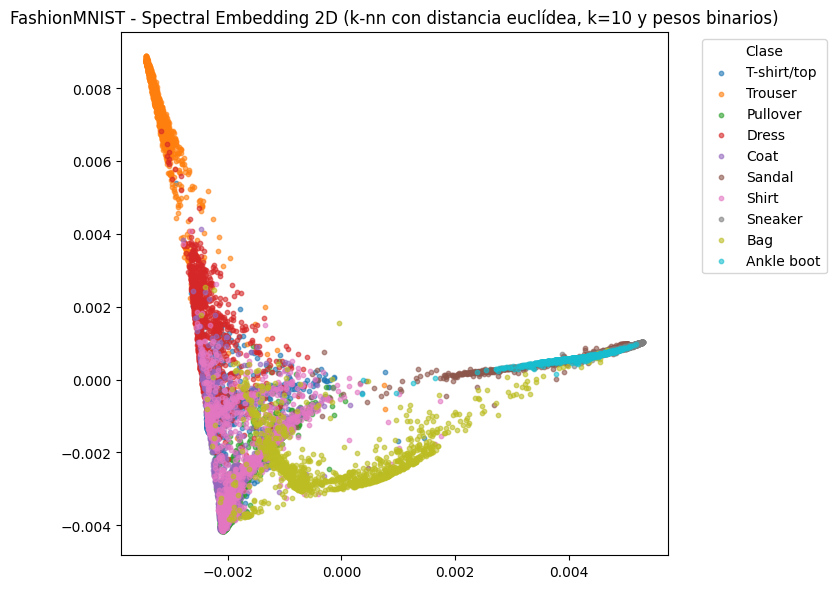

In [ ]:
# Importamos el algoritmo de aprendizaje no supervisado que implementa el laplacian
# eigenmap
from sklearn.manifold import SpectralEmbedding

# valor óptimo del hiperparámetro para k-nn con la distancia euclídea
n_neighbors = 10

# Todo por defecto. La matriz de afinidad es una matriz 'sparse' calculada usando
# k-nn con la distancia euclídea
se1 = SpectralEmbedding(n_components=2, affinity='nearest_neighbors',
                        n_neighbors=n_neighbors)
# Ajusta el subconjunto de datos de 12000 imágenes al modelo y devuelve X1, que
# es el spectral embedding resultante
X1 = se1.fit_transform(X)

representacion_scatter(X1, y, "FashionMNIST - Spectral Embedding 2D (k-nn con distancia euclídea, k=10 y pesos binarios)")

La variedad resultante nos permite interpretar bien los datos. Aún así, vamos a seguir probando más opciones.

**Forma 2. RBF denso.**

Una posibilidad, en lugar de utilizar pesos binarios, es utilizar un kernel para definir los pesos entre los datos (vectores de píxeles que representan las imágenes). El más utilizado en la [literatura](https://arxiv.org/pdf/2106.02154) es el RBF, que nos puede ser de utilidad en el *laplacian eigenmap* si nos interesa que los puntos más próximos tengan una afinidad mayor, y no solo saber si son vecinos o no.

En este caso, la matriz de pesos se define como $W_{ij}=exp(-\gamma \parallel x_i - x_j \parallel ^2)$, donde conviene definir razonablemente el parámetro $\gamma$, pues si no sklearn lo establece por defecto a $\frac{1}{784}$. Como queremos que la escala del núcleo refleje la estructura local del grafo de vecinos, tomaremos $\gamma=1/(2 \sigma^2)$, siendo $\sigma$ la mediana al $k$-ésimo vecino. Esta elección es muy típica para kernels RBF, como exponen en este [paper](https://arxiv.org/pdf/1707.07269), pues adapta el ancho del kernel a las distancias de los datos y evita afinidades casi todas iguales o casi todas nulas. De este modo:


*   $\sigma$ es la mediana de las distancias (euclídeas) al $k$-ésimo vecino (tomando $k=10$), y mide el ancho del núcleo.
*   $\gamma$ es la inversa de la varianza multiplicada por una constante, y mide la precisión local del núcleo
* El RBF utilizado coincide con el [núcleo gaussiano](https://www.geeksforgeeks.org/machine-learning/gaussian-kernel/).

In [ ]:
# Calculamos sigma como la mediana de las distancias euclídeas de cada dato a
# sus 10 vecinos más cercanos
sigma = np.median(dist_eu[:, n_neighbors - 1])
# Definimos gamma a partir de sigma
gamma = 1 / (2 * sigma**2)

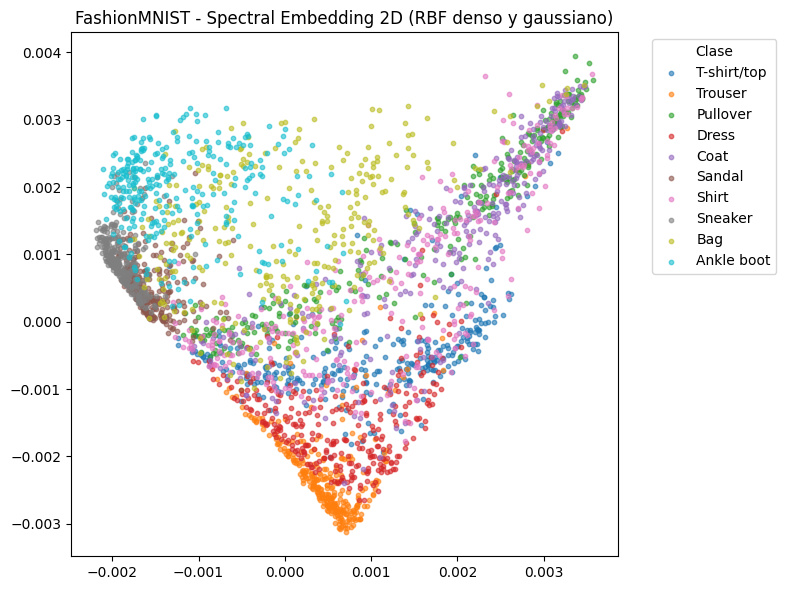

In [ ]:
# Entrenamos el laplacian eigenmap utilizado el RBF con parámetro gamma como hemos
# descrito arriba
se2 = SpectralEmbedding(n_components=2, affinity='rbf', gamma=gamma)
# Ajustamos el subconjunto de 3000 imágenes al modelo y obtenemos X2, que es la
# variedad de dimensión 2 que mejor representa la estructura local no lineal de
# dichas imágenes
X2 = se2.fit_transform(X_rbf)

representacion_scatter(X2, y_rbf, "FashionMNIST - Spectral Embedding 2D (RBF denso y gaussiano)")

¿Qué hubiera pasado si dejamos el parámetro $\gamma$ por defecto? La respuesta, a continuación.

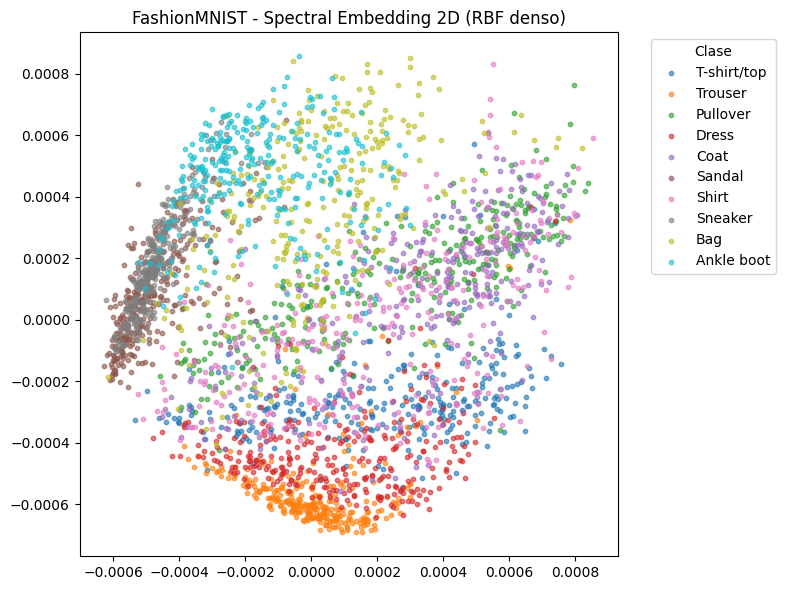

In [ ]:
# Entrenamos el laplacian eigenmap utilizado el RBF con el gamma por defecto
se2_sin_gamma = SpectralEmbedding(n_components=2, affinity='rbf')
# Ajustamos el subconjunto de 3000 imágenes al modelo y obtenemos X2_sin_gamma
X2_sin_gamma = se2_sin_gamma.fit_transform(X_rbf)

representacion_scatter(X2_sin_gamma, y_rbf, "FashionMNIST - Spectral Embedding 2D (RBF denso)")

Esta segunda forma de construir la matriz de afinidad no parece la más adecuada, independientemente del parámetro $\gamma$ elegido, pues aún así hay demasiada dispersión entre las imágenes de la misma clase.

**Forma 3. $k-nn$ con pesos dados por el núcleo RBF (utilizando la distancia euclídea)**

En la segunda forma explicada, hemos definido la afinidad entre vectores de píxeles mediante un kernel RBF. No obstante, para explotar aún más la idea de vecindad local sobre la que se apoya el *laplacian eigenmap*, planteamos una segunda formulación: construir primero el grafo $k-nn$ y, una vez fijada esa estructura local, asignar pesos a las aristas mediante un kernel RBF.

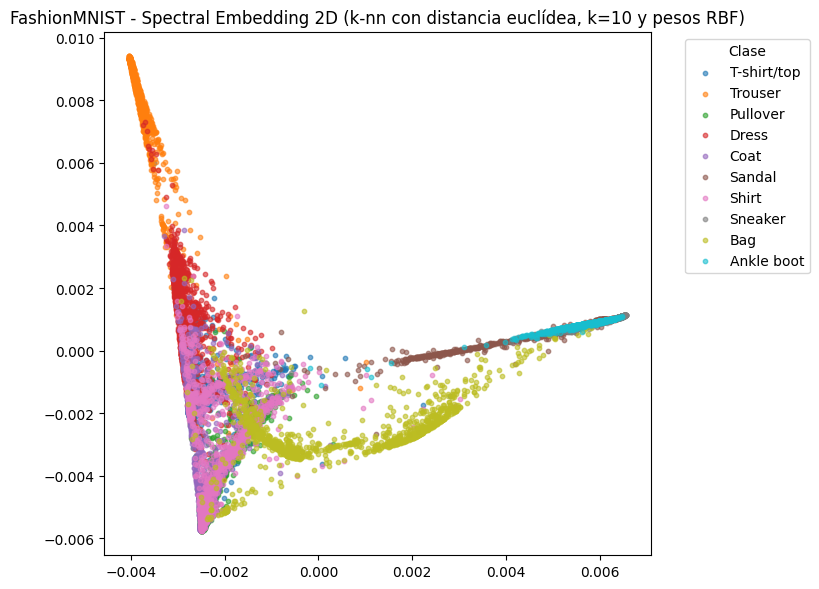

In [ ]:
from sklearn.neighbors import kneighbors_graph

# Cálculo de la matriz de afinidad
# Construimos el grafo k-nn usando como pesos las distancias euclídeas entre vecinos
# include_self=False no marca a cada nodo como su primer vecino
A = kneighbors_graph(X, n_neighbors=n_neighbors, mode='distance', include_self=False)

# Transformamos esas distancias en afinidades mediante un kernel RBF
A.data = np.exp(-A.data**2 * gamma)
W3 = (A + A.T) # simetrizar sumando
W3.data /= 2 # promedio donde se solapan (altera algunas distancias)

# Entrenamos el modelo utilizando la matriz de afinidad que hemos construido
se3 = SpectralEmbedding(n_components=2, affinity='precomputed')
# Ajustamos los datos para obtener la variedad resultante
X3 = se3.fit_transform(W3)

representacion_scatter(X3, y, "FashionMNIST - Spectral Embedding 2D (k-nn con distancia euclídea, k=10 y pesos RBF)")

Observamos que la variedad obtenida es muy similar a la obtenida mediante la forma 1. Así, parece que al aplicar $k-nn$ con $k=10$ da igual si definimos los pesos de forma binaria o con el núcleo RBF, pues el *embedding* obtenido en 2D es esencialmente el mismo.

**Forma 4.  $k-nn$ usando la distancia coseno para encontrar los vecinos.**

La última prueba que hacemos es con la distancia coseno, que hemos explicado anteriormente. Recordamos que aquí habíamos decidido que $k=15$ era el valor del hiperparámetro óptimo para aplicar este algoritmo.

De este modo, primero construimos la matriz de afinidad asignando pesos binarios.

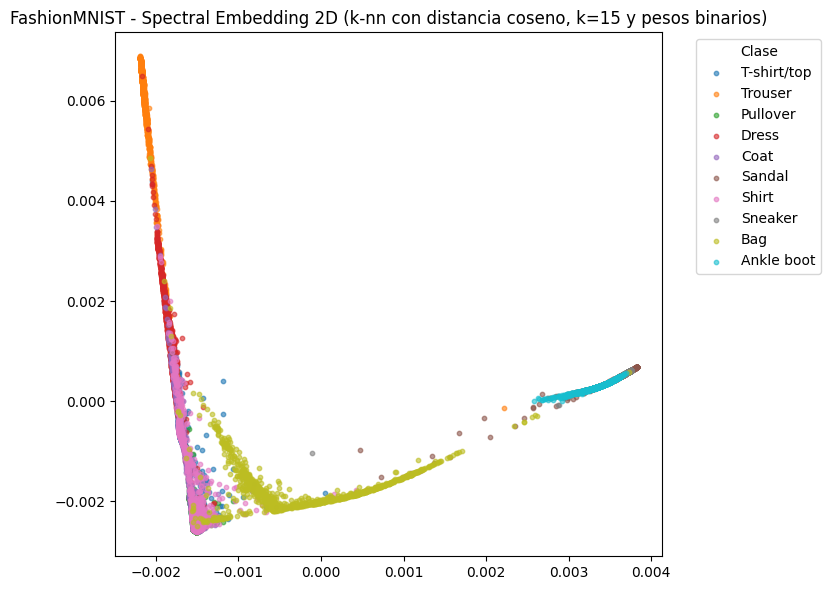

In [ ]:
from sklearn.metrics import pairwise_distances

# Calcula la distancia coseno entre todos los pares de puntos del dataset con
# 12000 imágenes
D = pairwise_distances(X, metric='cosine')
# Hiperparámetro óptimo para aplicar k-nn con esta distancia
n_neighbors = 15

# Construir matriz de afinidad k-nn a partir de la matriz de distancias
# Número de imágenes en el subconjunto del dataset
n = D.shape[0]
# Matriz del tamaño de D con todo ceros
W4 = np.zeros_like(D)
for i in range(n):
    # Tomamos los índices de los n_neighbors+1 puntos más cercanos a i
    # (incluyendo al propio punto i, cuya distancia a sí mismo es 0)
    idx = np.argpartition(D[i], n_neighbors + 1)[:n_neighbors + 1]
    # excluimos el propio punto
    idx = idx[idx != i][:n_neighbors]

    # Marcamos con 1 las conexiones desde i hacia esos vecinos
    W4[i, idx] = 1

# Simetrizamos la matriz
W4 = 0.5 * (W4 + W4.T)

# entrenamos el modelo utilizando la matriz de afinidad que hemos construido
se4 = SpectralEmbedding(n_components=2, affinity='precomputed')
# ajustamos el subconjunto de 12000 imágenes al modelo y obtenemos la variedad
# resultante
X4 = se4.fit_transform(W4)

representacion_scatter(X4, y, "FashionMNIST - Spectral Embedding 2D (k-nn con distancia coseno, k=15 y pesos binarios)")

Aquí observamos que la distancia coseno genera un *embedding* 2D más fino y comprimido, con ramas estrechas y poca dispersión interna. En cambio, la variedad generada con la distancia euclídea en 2D (mediante la forma 1) queda más abierta y extendida, lo que permite apreciar mejor cierta variabilidad dentro de algunas clases.

Para completar la comparativa, vamos a construir la matriz de afinidad precomputada usando de nuevo la distancia coseno, pero asignando ahora los pesos mediante el núcleo RBF.

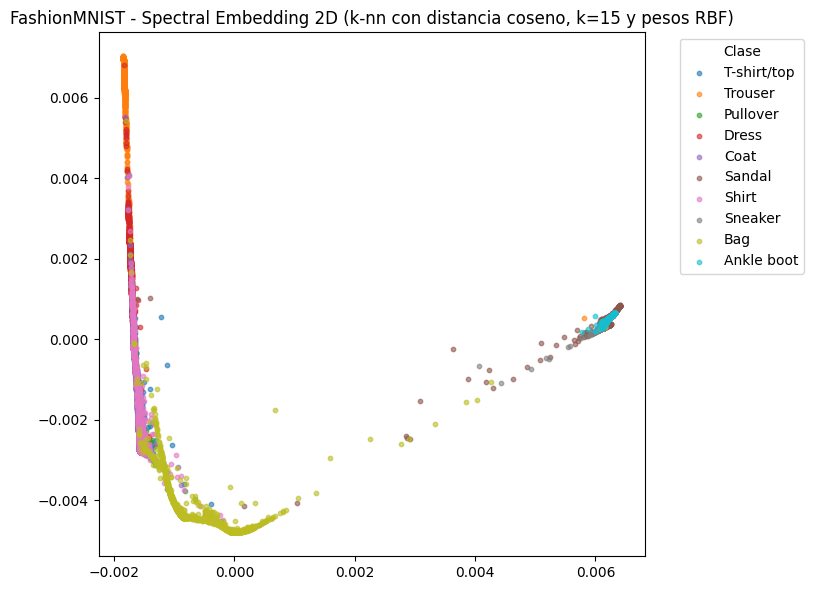

In [ ]:
# Escala local: mediana de la distancia al vecino k-ésimo
sigma = np.median(np.sort(D, axis=1)[:, n_neighbors])
gamma = 1 / (2 * sigma**2)

# Matriz de afinidad k-nn con pesos RBF
W4_rbf = np.zeros_like(D)

for i in range(n):
    # Índices de los k vecinos más cercanos (más el propio punto)
    idx = np.argpartition(D[i], n_neighbors + 1)[:n_neighbors + 1]
    # Excluimos el propio punto
    idx = idx[idx != i][:n_neighbors]

    # Pesos RBF usando distancia coseno
    W4_rbf[i, idx] = np.exp(-gamma * D[i, idx]**2)

# Simetrizar
W4_rbf = 0.5 * (W4_rbf + W4_rbf.T)

# entrenamos el modelo utilizando la matriz de afinidad que hemos construido
se4_rbf = SpectralEmbedding(n_components=2, affinity='precomputed')
# ajustamos el subconjunto de 12000 imágenes al modelo y obtenemos el embedding
# resultante
X4_rbf = se4_rbf.fit_transform(W4_rbf)

representacion_scatter(X4_rbf, y,"FashionMNIST - Spectral Embedding 2D (k-nn con distancia coseno, k=15 y pesos RBF)")

La conclusión obtenida al utilizar $k-nn$ con la distancia coseno y con los pesos determinados mediante el núcleo RBF es similar a la que dijimos cuando calculábamos los pesos binarios. La variedad queda muy compacta, y no es tan explicativa como nos gustaría.

**Conclusión.** A la vista de las variedades obtenidas en 2D, parece que la opción más razonable es construir la matriz de afinidad utilizando el algoritmo $k-nn$ con el valor del hiperparámetro $k=10$. Podemos asignar los pesos de forma binaria o mediante el kernel RBF, tal vez la primera opción sea mejor porque evitamos precomputar la matriz "a mano", luego gastamos menos recursos computacionales y reducimos el tiempo de ejecución.

No obstante, como trabajo futuro, podríamos explorar nuevas distancias para ver si funcionan mejor con estos datos concretos. Por ejemplo, podríamos considerar una distancia mixta entre la euclídea y la coseno, la métrica de Jaccard, etc.

**3. Detalles del *spectral embedding***

**Representación en 2D**

Comenzamos por mostrar el *embedding* obtenido de dos maneras, para realizar una primera interpretación:

1. La representación mostrada en la sección anterior.
1. Una representación en la que vemos las imágenes del *dataset* en la forma del *embedding*.

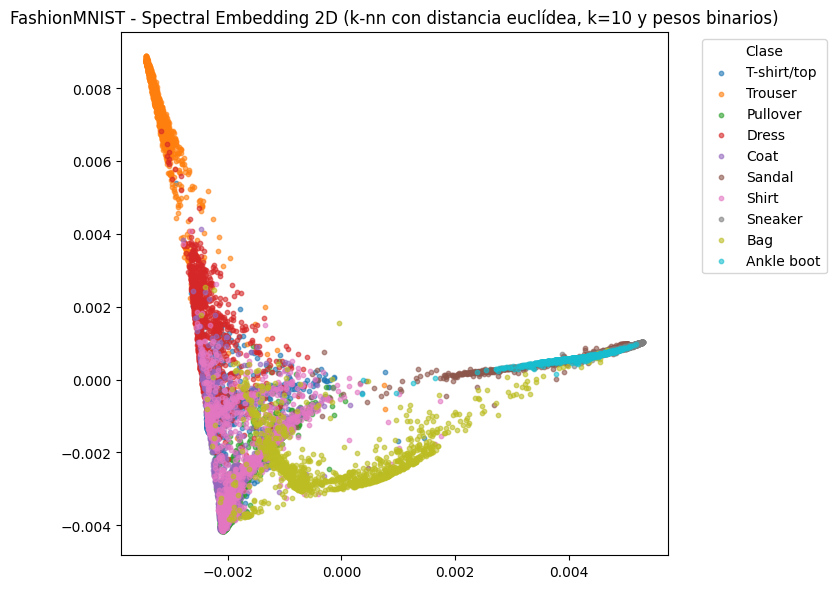

In [ ]:
from sklearn.manifold import SpectralEmbedding
# Primera representación

# valor óptimo del hiperparámetro para k-nn con la distancia euclídea
n_neighbors = 10

# Todo por defecto. La matriz de afinidad es una matriz 'sparse' calculada usando
# k-nn con la distancia euclídea
se1 = SpectralEmbedding(n_components=2, affinity='nearest_neighbors',
                        n_neighbors=n_neighbors)
# Ajusta el subconjunto de datos de 12000 imágenes al modelo y devuelve X1, que
# es el spectral embedding resultante
X1 = se1.fit_transform(X)

representacion_scatter(X1, y, "FashionMNIST - Spectral Embedding 2D (k-nn con distancia euclídea, k=10 y pesos binarios)")

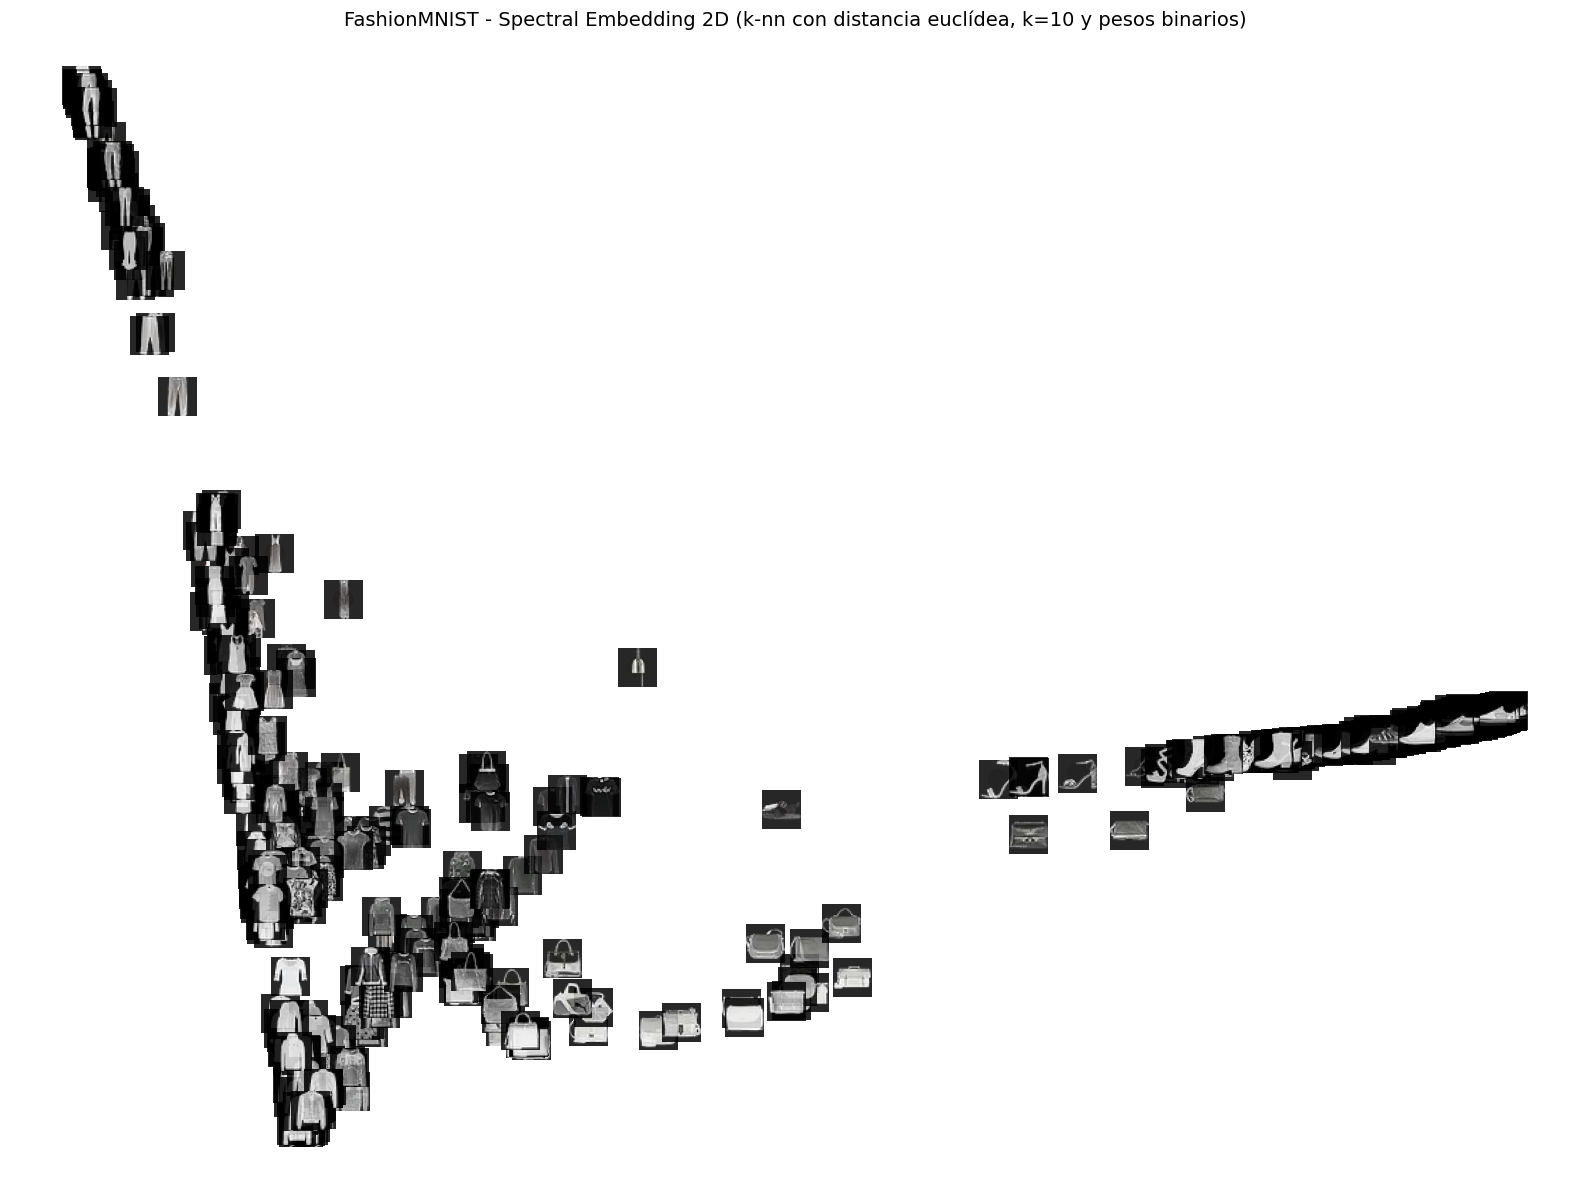

In [ ]:
# Segunda representación

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Parámetros de visualización
ZOOM = 1
ALPHA = 0.85
N_SHOW = 500

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X1), size=min(N_SHOW, len(X1)), replace=False)

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor("#f8f8f8")

for i in idx:
    img = X[i]
    if hasattr(img, "numpy"):
        img = img.numpy()
    img = img.squeeze()
    img = img.reshape(28, 28)

    imagebox = OffsetImage(img, zoom=ZOOM, alpha=ALPHA, cmap="gray")
    ab = AnnotationBbox(
        imagebox,
        (X1[i, 0], X1[i, 1]),
        frameon=False,
        pad=0
    )
    ax.add_artist(ab)

scatter = ax.scatter(
    X1[idx, 0], X1[idx, 1],
    c=y[idx], cmap="tab10",
    s=200, alpha=0.15, zorder=0  # detrás de las imágenes
)

margin = 0.05
x_range = np.ptp(X1[idx, 0])
y_range = np.ptp(X1[idx, 1])
ax.set_xlim(X1[idx, 0].min() - margin * x_range,
            X1[idx, 0].max() + margin * x_range)
ax.set_ylim(X1[idx, 1].min() - margin * y_range,
            X1[idx, 1].max() + margin * y_range)

ax.set_title("FashionMNIST - Spectral Embedding 2D (k-nn con distancia euclídea, k=10 y pesos binarios)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

Como primera interpretación, observamos que el algoritmo de *spectral embedding* da una estructura con cierta lógica, dadas las imágenes del *dataset*. Observamos en particular que:

1. Se agrupa el calzado en la misma zona del *embedding*, y hay una suerte de continuo desde zapatos abiertos, a botines y finalmente a zapatillas.
1. Las prendas como abrigos, chaquetas y camisetas se agregan en la misma zona del *embedding*, y también parece verse un «continuo» como el anterior, aunque es menos evidente.
1. En el extremo superior izquierdo, encontramos el fin del «continuo» que apuntábamos antes: las camisetas pasan a ser vestidos, que pasan a ser pantalones.
1. Los bolsos, bastante distintos a todo lo demás, tienen su propia región en el *embedding*.

Hasta ahora, hemos estado realizando las transformaciones en 2 dimensiones, con el fin de proporcionar una interpretación intuitiva, pero podemos trabajar en más dimensiones modificando el parámetro `n_components` de la clase `SpectralEmbedding`.

Primero, realizamos una representación en 3 dimensiones, para ver si puede resultar de ayuda este enfoque, y posteriormente, estudiaremos los autovalores del Laplaciano del grafo, que es la herramienta principal del algoritmo, para ver si somos capaces de localizar un codo que nos permita obtener la máxima información posible.

**Representación en 3D**

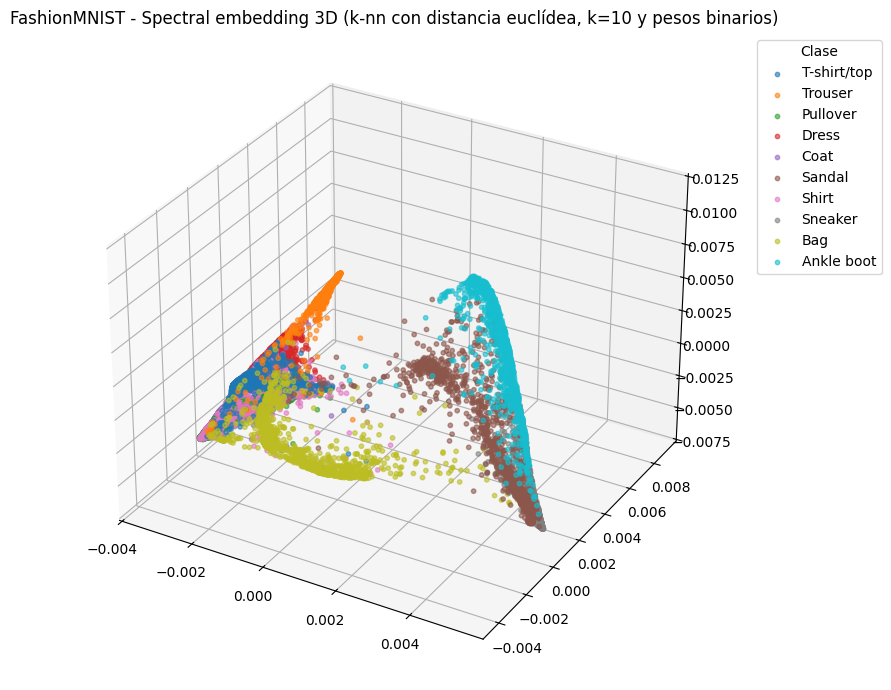

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # necesario importarlo aunque no se use directamente

se1 = SpectralEmbedding(n_components=3, affinity='nearest_neighbors',
                        n_neighbors=n_neighbors)
# Ajusta el subconjunto de datos de 12000 imágenes al modelo y devuelve X1, que
# es el spectral embedding resultante en 3D
X1_3d = se1.fit_transform(X)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

classes = np.unique(y)
cmap = plt.get_cmap('tab10')

for i, c in enumerate(classes):
    mask = y == c
    ax.scatter(X1_3d[mask, 0], X1_3d[mask, 1], X1_3d[mask, 2],
               label=label_names[c],
               color=cmap(i),
               s=10,
               alpha=0.6)

ax.set_title("FashionMNIST - Spectral embedding 3D (k-nn con distancia euclídea, k=10 y pesos binarios)")
ax.legend(title='Clase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Se observa claramente la distinción en 4 categorías principales:

*   Camisetas, camisas y abrigos.
*   Pantalones.
* Bolsos.
* Zapatos

Además,  en la región de zapatos, la tercera dimensión ha permitido separar los botines del calzado abierto.

**Estudio de la dimensión óptima de la variedad (realizado sobre autovalores del Laplaciano)**

Emplearemos el atributo `_affinity_matrix` de `SpectralEmbedding`.

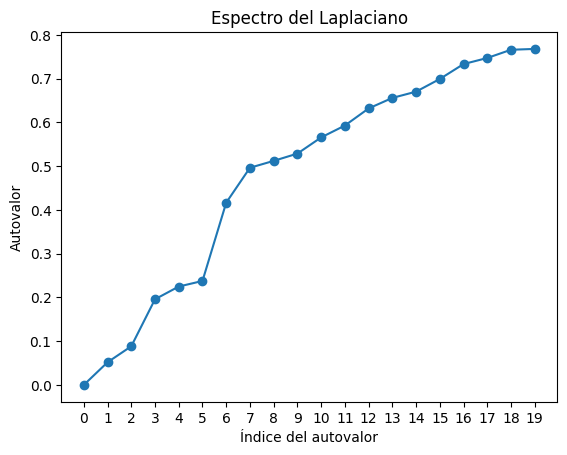

In [ ]:
# Para calcular autovalores y autovectores de matrices simétricas sparse (con muchos
# 0s o valores repetidos)
from scipy.sparse.linalg import eigsh
# Para construir el laplaciano a partir de la matriz de afinidad
from scipy.sparse.csgraph import laplacian

# Creamos el modelo con más componentes de los utilizados hasta ahora
se = SpectralEmbedding(n_components=20)
# Ajustamos el modelo a los datos
se.fit(X)

# Los autovalores no están expuestos directamente en sklearn,
# pero se calculan a partir de la matriz de afinidad construida
W = se.affinity_matrix_  # matriz de afinidad

# Construcción del laplaciano normalizado
L = laplacian(W, normed=True)
# eigsh calcula los 20 autovalores más pequeños en magnitud de L (Small Magnitude)
vals, _ = eigsh(L, k=20, which='SM')
# Los ordenamos de menor a mayor
vals = np.sort(vals)

plt.plot(range(len(vals)), vals, marker='o')
plt.xticks(range(len(vals)))
plt.xlabel('Índice del autovalor')
plt.ylabel('Autovalor')
plt.title('Espectro del Laplaciano')
plt.show()

Lo primero que llama nuestra atención es que el autovalor más pequeño es nulo, esto es, vale exactamente cero. Es más, el hecho de que no haya varios autovalores nulos nos sugiere que el grafo tiene una única componente conexa, o que al menos no hay varias componentes conexas claramente separadas. Intuitivamente, vemos que el codo del espectro está en el 6º autovalor (marcado con índice 5 en la gráfica), luego como descartamos el primero, parece que el *embedding* que mejor representa la información del dataset es el que tiene `n_components=5`.

**Conclusión.** Parece que con una variedad (no lineal) de dimensión 5 representamos la mayor parte de la estructura y geometría de los datos.

**4. Relación con el _spectral clustering_**

Mediante el algoritmo de _spectral embedding_, hemos practicado una reducción de la dimensionalidad sobre el *dataset*, llevándolo de 784 dimensiones a 2, 3 ó 5.

Como apunta el [paper](https://www2.imm.dtu.dk/projects/manifold/Papers/Laplacian.pdf), *spectral embedding* y *spectral clustering* son dos caras de la misma moneda, y, si el *embedding* es un «soft-clustering», podemos aplicar algoritmos empíricos (como [KMeans](https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/)) para hacer un «hard-clustering» que etiquete los datos que tenemos.

Procedemos de la siguiente manera:

1. Vamos a aplicar KMeans a los *embeddings* que tenemos en 2, 3 y 5 dimensiones (2 y 3 porque son fácilmente interpretables, y 5 porque es donde pensamos que se explica más información).
1. Vamos a intentar buscar 10 clústeres y a estudiar cuánto se parecen a las clases de las que disponíamos al principio, haciendo una especie de «supervisión».

In [ ]:
# Función auxiliar para pintar mapas de calor (matrices de confusión)

import seaborn as sns
from sklearn.metrics import confusion_matrix

def representacion_matriz(y, cluster_labels):
  # Tabla de doble entrada
  cm = confusion_matrix(y, cluster_labels)

  conf_df = pd.DataFrame(
      cm,
      index=[f"{i} – {label_names[i]}" for i in range(len(label_names))],
      columns=[f"Cluster {i}" for i in range(N_CLUSTERS)]
  )

  print(conf_df.to_string())

  # Heatmap
  fig, ax = plt.subplots(figsize=(9,6))

  sns.heatmap(
      conf_df,
      annot=True,
      fmt="d",
      cmap="YlOrRd",
      linewidths=0.5,
      linecolor="white",
      ax=ax,
      cbar_kws={"label": "Número de muestras"}
  )

  ax.set_title("Clase original vs. Cluster asignado — FashionMNIST", fontsize=14, pad=15)
  ax.set_xlabel("Cluster asignado (KMeans)", fontsize=12)
  ax.set_ylabel("Clase original", fontsize=12)
  ax.tick_params(axis='x', rotation=45)
  ax.tick_params(axis='y', rotation=0)

  plt.tight_layout()
  plt.show()

**Spectral clustering en 2D**

Veamos primero qué ocurre cuando ejecutamos el algoritmo con 10 centroides, con la idea de forma 10 clústeres (tantos como clases distintas hay en el *dataset* Fashion MNIST). Esto no significa que $K=10$ sea el valor óptimo del hiperparámetro.

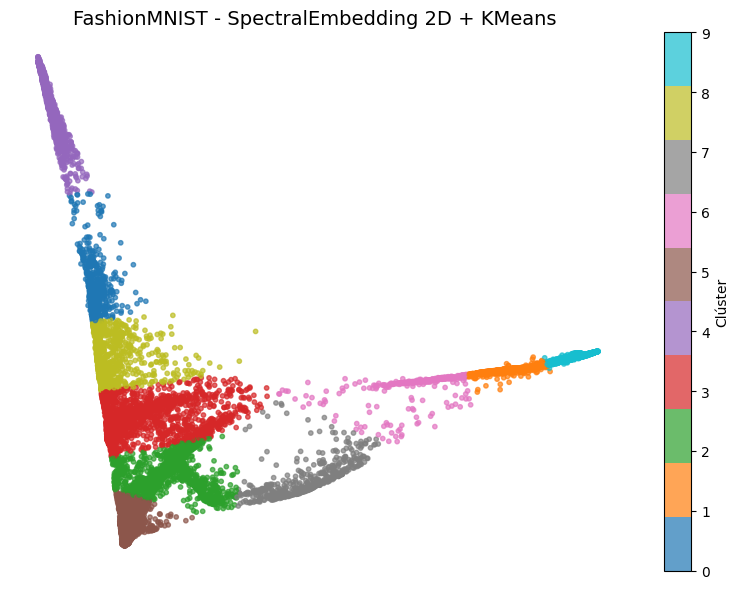

In [ ]:
from sklearn.cluster import KMeans

N_CLUSTERS = 10  # FashionMNIST tiene 10 clases

# Aplica el algoritmo kmeans para clustering
# n_clusters determina el número de clústeres y centroides a generar
# random_state inicializa los centroides de forma determinista
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

# fit ajusta el modelo kmeans a la variedad 2d
# predict asigna a cada dato una etiqueta de clase
cluster_labels = kmeans.fit_predict(X1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor("#f8f8f8")

# Recorremos todos los puntos de la variedad
idx = range(len(X1))

# Cada punto se pinta del color de su clúster
scatter = ax.scatter(
    X1[idx, 0],
    X1[idx, 1],
    c=cluster_labels[idx],
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ax=ax, label="Clúster")
ax.set_title("FashionMNIST - SpectralEmbedding 2D + KMeans ", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

**Comparación entre clústeres y clases originales**

                 Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6  Cluster 7  Cluster 8  Cluster 9
0 – T-shirt/top          9          0         53        969          1         29          1          5        133          0
1 – Trouser             85          0          6          9       1071         12          1          1         15          0
2 – Pullover             0          0        299        108          0        782          0          3          8          0
3 – Dress              464          0         21        184         10          7          0          0        514          0
4 – Coat                 5          0        173        211          0        737          0          2         72          0
5 – Sandal               0        347          1         10          0          0        272          2          1        567
6 – Shirt                4          0        283        448          0        386          3          8         68    

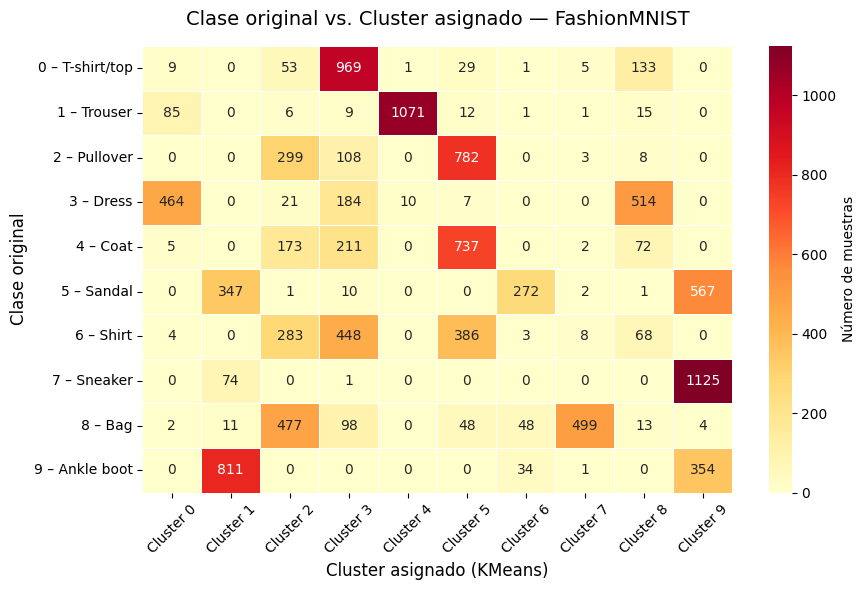

In [ ]:
representacion_matriz(y, cluster_labels)

**Spectral clustering en 3D**

Misma discusión que antes, solo que ahora con la variedad 3D. De nuevo, el valor de $K=10$ no tiene por qué ser el óptimo.

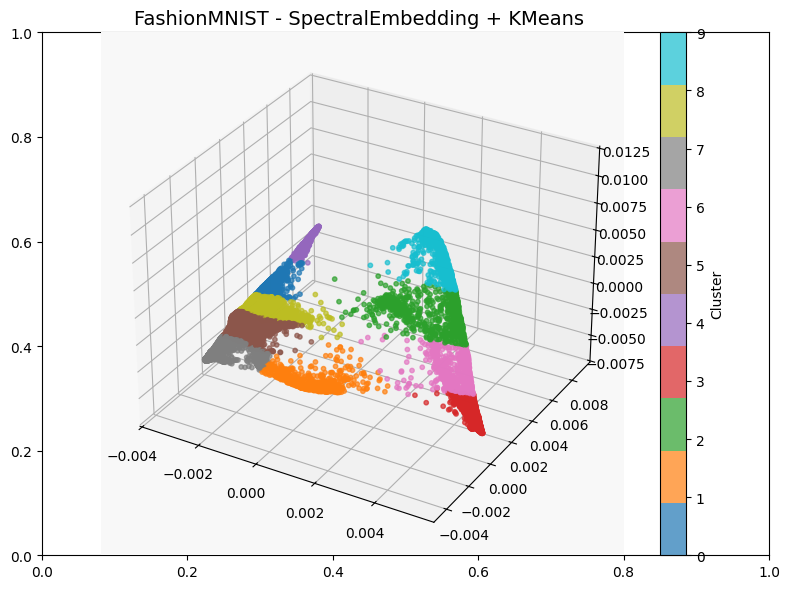

In [ ]:
N_CLUSTERS = 10  # FashionMNIST tiene 10 clases

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X1_3d)

fig, ax = plt.subplots(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor("#f8f8f8")

idx = range(len(X1))

scatter = ax.scatter(
    X1_3d[idx, 0],
    X1_3d[idx, 1],
    X1_3d[idx, 2],
    c=cluster_labels[idx],
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title("FashionMNIST - SpectralEmbedding + KMeans ", fontsize=14)
#ax.axis("off")
plt.tight_layout()
plt.show()

                 Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6  Cluster 7  Cluster 8  Cluster 9
0 – T-shirt/top         49          5          0          0          1        692          0         43        410          0
1 – Trouser             80          1          1          0       1081         10          0         13         14          0
2 – Pullover             1          1          0          0          0        294          0        874         30          0
3 – Dress              707          0          0          0         11         77          0         10        395          0
4 – Coat                13          1          0          0          0        242          0        795        149          0
5 – Sandal               0          1        379        528          0          4        229          0         16         43
6 – Shirt               10         10          0          0          0        469          0        457        254    

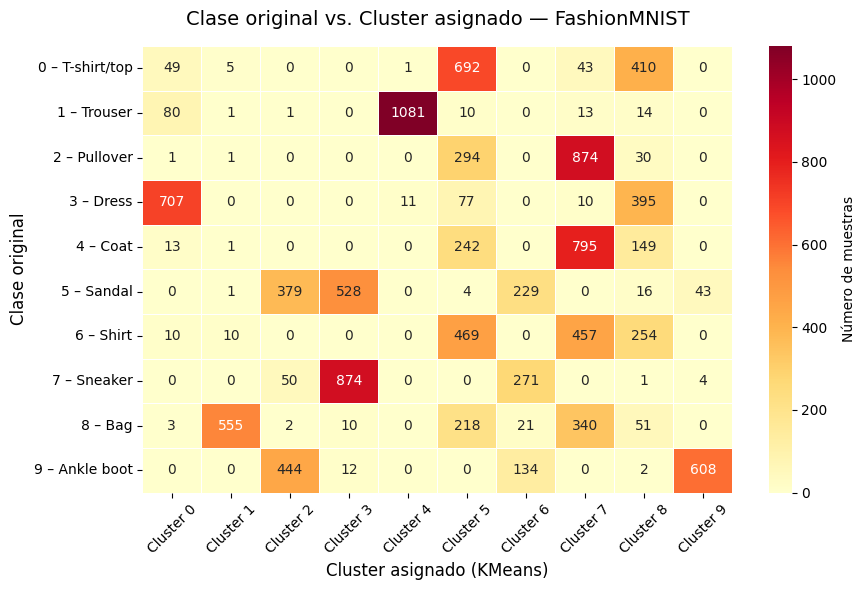

In [ ]:
representacion_matriz(y, cluster_labels)

**Spectral clustering en 5D**

                 Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6  Cluster 7  Cluster 8  Cluster 9
0 – T-shirt/top        384         21          0          6          1          0        694          0         94          0
1 – Trouser             76         12          0          0       1096          0          0          0         15          1
2 – Pullover            17        825          0          1          0          0          1          0        356          0
3 – Dress             1080          5          0          0         12          0         14          0         89          0
4 – Coat               137        764          0          2          0          0          3          0        294          0
5 – Sandal               2          0        237          1          0        520          0         43         18        379
6 – Shirt              212        390          1          8          0          0        177          0        412    

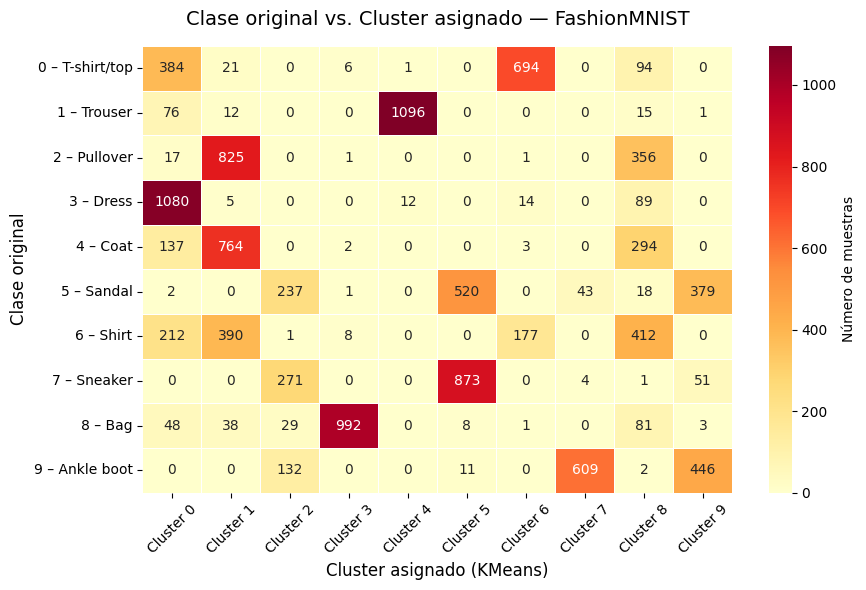

In [ ]:
n_neighbors = 10

# Primero hacemos el embedding con n_components=5
# Creamos el modelo con k-nn usando el hiperparámetro k=10
se1 = SpectralEmbedding(n_components=5, affinity='nearest_neighbors',
                        n_neighbors=n_neighbors)
# Ajustamos el modelo a nuestros datos
X1_5d = se1.fit_transform(X)

# Clustering k-means, igual que antes pero aplicado a la variedad 5d y utilizando
# k=10 clústeres y centroides
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X1_5d)

# Matriz de confusion
representacion_matriz(y, cluster_labels)

Observamos que, de entre todas las matrices de confusión generadas, esta última arroja los mejores resultados. Los clústeres formados a partir de la variedad 5D separan completamente los bolsos, los pantalones, y casi los vestidos. También separan bastante bien tema zapatos: distingue (a grandes rasgos) zapatillas, botines y calzado abierto.

Hasta ahora, la discusión que hemos realizado nos ha permitido ver cómo el algoritmo de clustering KMeans separa en 10 clústeres las imágenes del *dataset*, iniciando por tanto el algoritmo con 10 centroides aleatorios (que se irán actualizando). Este valor del hiperparámetro $K$ se ha elegido así debido al número de clases que hay en Fashion MNIST. Pero puede resultar conveniente hacer pruebas con otros valores, de modo que el clustering forme grupos totalmente sólidos, sin que haya prendas muy entremezcladas entre varias agrupaciones.

En este [blog](https://www.geeksforgeeks.org/machine-learning/ml-determine-the-optimal-value-of-k-in-k-means-clustering/) nos explican algunos criterios razonables para elegir dicho valor: el gráfico de codo o el índice de silueta. Hay más, como el índice de Davies-Bouldin o el de Calinski-Harabasz, pero estos de momento no los estudiaremos. Así, vamos a calcularlos para 2, 3 y 5 dimensiones, de manera que elijamos qué valor de $K$ nos forma clústeres más explicativos en cada caso. El código que sigue se encarga de esto.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Valores de K que vamos a probar
ks = range(2, 16)

# Vamos a hacer que KMeans se reinicie varias veces, para garantizar así estabilidad
N_INIT = 20

# Embeddings que queremos comparar
embeddings = {
    "2D": X1,
    "3D": X1_3d,
    "5D": X1_5d
}

In [ ]:
resultados = {}

# Iteramos para cada embedding del diccionario que antes hemos construido
for nombre, X_emb in embeddings.items():
    filas = []

    # Probamos todos los valores de K definidos en la lista
    for k in ks:
        # Inicializamos el algoritmo KMeans con K clústeres sobre el embedding actual
        # Usa las misma 20 inicializaciones deterministas siempre, que nos permiten
        # obtener mejores resultados que usar solo una
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
        # Ajusta los datos y asigna las etiquetas a los clústeres
        labels = km.fit_predict(X_emb)

        # Guardamos la inercia para el método del codo
        # y la silueta para medir separación de los clústeres
        filas.append({
            "K": k,
            # la inercia es la suma de cuadrados dentro del clúster
            "inercia": km.inertia_,
            "silhouette": silhouette_score(X_emb, labels)
        })

    # Convertimos los resultados de cada embedding en una tabla
    resultados[nombre] = pd.DataFrame(filas)

In [ ]:
resumen = []

for nombre, df in resultados.items():
    # Tomamos los valores de k y de inercia para localizar el codo
    x = df["K"].to_numpy(dtype=float)
    y = df["inercia"].to_numpy(dtype=float)

    # Normalizamos para que la detección del codo no dependa de la escala
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Construimos la recta entre el primer y el último punto de la curva
    p1 = np.array([x_norm[0], y_norm[0]])
    p2 = np.array([x_norm[-1], y_norm[-1]])

    # Calculamos la distancia de cada punto a esa recta
    # El punto con mayor distancia se toma como el "codo"
    num = np.abs(
        (p2[1] - p1[1]) * x_norm
        - (p2[0] - p1[0]) * y_norm
        + p2[0] * p1[1]
        - p2[1] * p1[0]
    )
    den = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2)
    distancias = num / den
    k_codo = int(df.loc[np.argmax(distancias), "K"])

    # Elegimos como mejor silueta el k cuyo valor de silhouette es máximo
    k_silueta = int(df.loc[df["silhouette"].idxmax(), "K"])

    # Si ambos criterios coinciden, usamos ese valor
    # Si no coinciden, nos quedamos con el de silueta y usamos el codo como contraste
    k_final = k_codo

    resumen.append({
        "embedding": nombre,
        "K_codo": k_codo,
        "K_silueta": k_silueta,
        "K_recomendado": k_final
    })

resumen_df = pd.DataFrame(resumen)
resumen_df

,embedding,K_codo,K_silueta,K_recomendado
0,2D,4,3,4
1,3D,5,4,5
2,5D,6,6,6


En la tabla resultante tras ejecutar la celda de código anterior se aprecian los distintos valores de $K$ recomendados tanto por el método del codo como por el índice de Silueta.

Ahora, graficamos los clústeres con el valor del hiperparámetro $K$ para KMeans que nos ha dado el método del codo. Nos gustaría que los grupos formados sean explicativos, compactos y que no haya prendas que pertenezcan a muchos clústeres distintos a la vez.

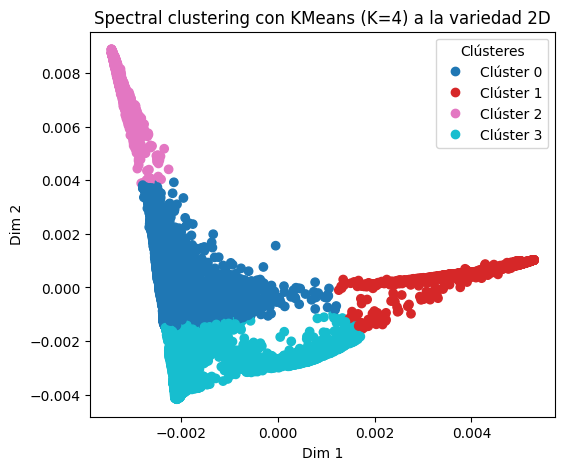

In [ ]:
labels_2d = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=N_INIT).fit_predict(X1)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X1[:, 0], X1[:, 1], c=labels_2d, cmap="tab10")

handles, _ = scatter.legend_elements()
ax.legend(handles, [f"Clúster {i}" for i in range(4)], title="Clústeres")

ax.set_title("Spectral clustering con KMeans (K=4) a la variedad 2D")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
plt.show()

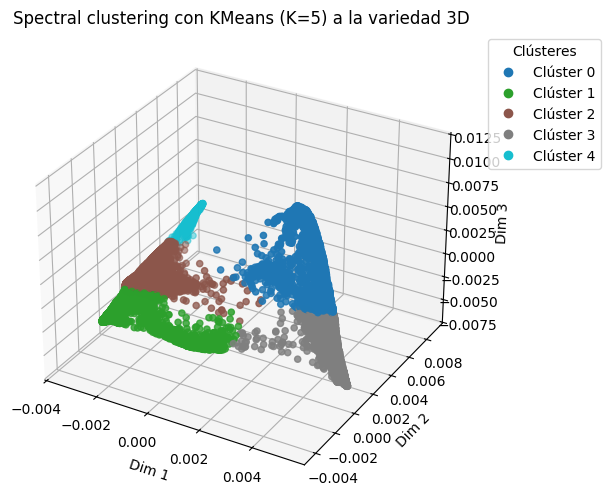

In [ ]:
labels_3d = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=N_INIT).fit_predict(X1_3d)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X1_3d[:, 0], X1_3d[:, 1], X1_3d[:, 2], c=labels_3d, cmap="tab10")

handles, _ = scatter.legend_elements()
ax.legend(handles, [f"Clúster {i}" for i in range(5)], title="Clústeres", loc="upper left", bbox_to_anchor=(1.02, 1))

ax.set_title("Spectral clustering con KMeans (K=5) a la variedad 3D")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
plt.show()

Los resultados no son los esperados. Aunque efectivamente el algoritmo forma los grupos que le hemos indicado, observamos que por ejemplo no separa bien todas las botas de todas las zapatillas, sino que la mitad de botas están en un clúster y la otra mitad están en otro.

Pero tal y como funciona KMeans, que agrupa los puntos en torno a un centroide, es imposible que el algoritmo realice la separación que nosotros deseamos. Una posible solución, que dejamos como trabajo futuro, es investigar otros algoritmos o técnicas empíricas mediantes las cuales realizar el clustering.

----------------------------------------------------------------------
**Bonus track**

Una duda razonable que nos podemos plantear es por qué no haber reducido la dimensionalidad del dataset utilizando otras técnicas de reducción de la dimensionalidad, como por ejemplo PCA.

Pues bien, la respuesta es sencilla: la estructura del dataset Fashion MNIST no es lineal, luego el Análisis de Componentes Principales no funciona bien para esta tarea. Comprobamos esta afirmación a continuación.

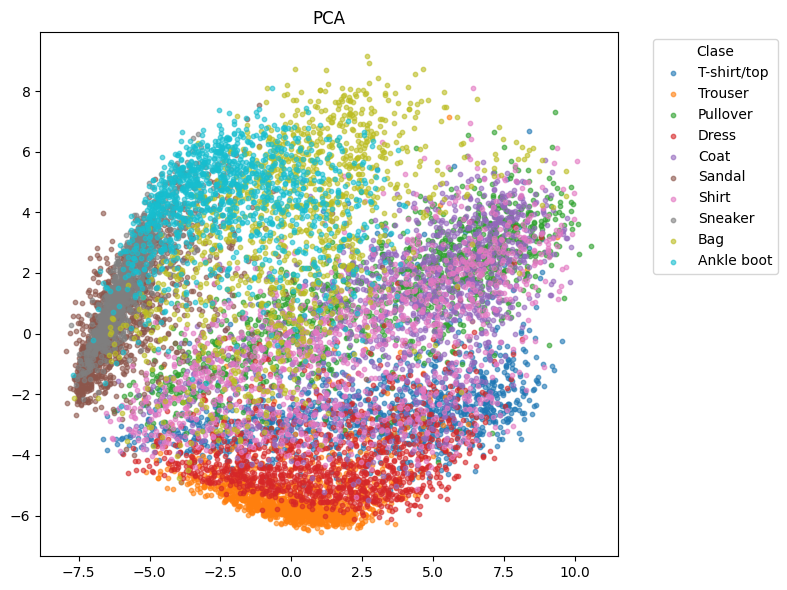

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

representacion_scatter(X_pca, y, "PCA")

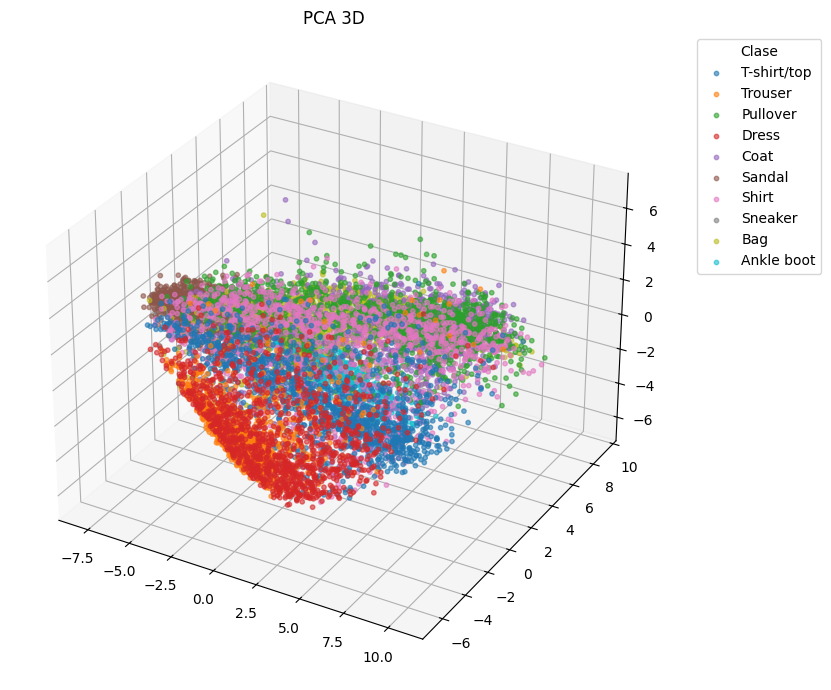

In [ ]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

classes = np.unique(y)
cmap = plt.get_cmap('tab10')

for i, c in enumerate(classes):
    mask = y == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
               label=label_names[c],
               color=cmap(i),
               s=10,
               alpha=0.6)

ax.set_title("PCA 3D")
ax.legend(title='Clase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Observamos que PCA no consigue dar una estructura 2D ni 3D claramente interpretable. Luego la estructura del dataset no es lineal y hemos hecho bien en aplicar *spectral embedding* como algoritmo no supervisado de reducción de la dimensionalidad.